In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [2]:
def u_true(x, t = 0.1, D = 1., sigma_0 = 0.1):
    """
    Analytic solution of 1D diffusion equation starting from Gaussian ICs.

    array (float) x: space grid
    float t: t_final
    float D: diffusion coefficient
    float sigma_0: Gaussian width

    returns:
    array (float): analytic solution for given space grid
    """
    sigma2 = sigma_0**2 + 2*D*t
    return 1/np.sqrt(2*np.pi*sigma2)*np.exp(-x**2/(2*sigma2))

def initial_conditions(x, sigma_0 = 0.1, t = 0.):
    """
    Gaussian initial conditions.

    array (float) x: space grid
    float D: diffusion coefficient
    float sigma_0: Gaussian width
    float t: time (set = 0)
    
    returns:
    array (float): initial conditions for given space grid
    """
    
    return 1/(np.sqrt(2*np.pi)*sigma_0)*np.exp(-x**2/(2*sigma_0**2))
    

In [3]:
def apply_bc(u):
    """
    Apply Dirichlet boundary conditions (u[L] = u[L-1] = 0)
    
    array (float) u: solution at time n
    
    returns:
    array (float): solution at time n with boundary conditions applied 
    """
    u_work = u.copy()
    u_work[0] = 0.
    u_work[-1] = 0.

    return u_work

In [4]:
#reminder: np.roll(u_current, -1) = u(n,j+1) and np.roll(u_current, +1) = u(n,j-1)
def ftcs(u, r):
    """
    FTCS step for 1D diffusion.
    
    array (float) u: solution at time n
    float r: dimensionless diffusion number
    
    returns:
    array (float): solution at time n+1 with boundary conditions applied
    """
    u_work = u.copy()
    u_work = u_work + r*(np.roll(u_work, -1) - 2*u_work + np.roll(u_work, 1))
    u_work = apply_bc(u_work)
    return u_work

def crank_nicolson(u, r):
    """
    Crank-Nicolson step for 1D diffusion.
    
    array (float) u: solution at time n
    float r: dimensionless diffusion number
    
    returns:
    array (float): solution at time n+1 with boundary conditions applied
    """
    u_work = thomson(u,r, 'crank-nicolson')
    u_work = apply_bc(u_work)
    return u_work

def fully_implicit(u, r):
    """
    Fully implicit step for 1D diffusion.
    
    array (float) u: solution at time n
    float r: dimensionless diffusion number
    
    returns:
    array (float): solution at time n+1 with boundary conditions applied
    """
    u_work = thomson(u,r, 'fully implicit')
    u_work = apply_bc(u_work)
    return u_work

def thomson(u,r, method):
    """
    Thomson algorithm for tridiagonal systems.
    
    array (float) u: solution at time n
    float r: dimensionless diffusion number
    string method: implicit scheme to diagonalize. Can be Crank Nicolson or fully implicit method
    
    returns:
    array (float): solution at time n+1 with no boundary conditions applied yet
    """
    u_work = u.copy()

    #define tridiagonal coefficients for Crank Nicolson method
    if method == 'crank-nicolson':
        a = -r/2
        b = 1+r
        c = -r/2

        d = 0.5*r*np.roll(u_work, 1) + (1-r)*u_work + 0.5*r*np.roll(u_work, -1)
        d = d[1:-1] #avoid boundary
    
    #define tridiagonal coefficients for fully implicit method 
    if method == 'fully implicit':
        a = -r
        b = 1+2*r
        c = -r

        d = u_work.copy()
        d = d[1:-1] #avoid boundary
        
    #Thomas forward sweep
    m = len(u)-2
    c_prime = np.zeros(m)
    d_prime = np.zeros(m)

    c_prime[0] = c/b
    d_prime[0] = d[0]/b

    #compute by iteration interior coefficients
    for i in range(1, m):
        denom = b - a * c_prime[i-1]
        c_prime[i] = c / denom if i < m-1 else 0.0
        d_prime[i] = (d[i] - a * d_prime[i-1]) / denom

    #back substitution
    u_work[-2] = d_prime[-1]       #avoid u_work[-1] (boundary point)
    for i in range(m-2, -1, -1):   
        u_work[i+1] = d_prime[i] - c_prime[i]*u_work[i+2] #avoid u_work[0], u_work[-1] with i+1, i+2 (boundary points)

    return u_work

In [5]:
def model(dx, A, p):
    """ 
    Model function to obtain the slope of the error curve in log-log scale.
    array (float) dx: step size
    float A: constant factor
    float p: order of the method (slope in log-log scale)

    returns:
    array (float): estimated errors from step size
    """
    return A * dx**p

In [6]:
D = 1.
sigma_0 = 0.1
L = 3.
t_final = 0.1
nx = 401
x = np.linspace(-L, L, nx)
dx = x[1]-x[0]


In [7]:
r = 0.4
dt = r*dx**2/D
steps = int(np.ceil(t_final/dt))
dt = t_final/steps
r = D*dt/dx**2

u_stable = initial_conditions(x)
u_stable = apply_bc(u_stable)
times_stable = []

for n in range(steps):
    u_stable = ftcs(u_stable, r)
    times_stable.append(n*dt)

r = 0.6
dt = r*dx**2/D
steps = int(np.ceil(t_final/dt))
dt = t_final/steps
r = D*dt/dx**2

u_unstable = initial_conditions(x)
u_unstable = apply_bc(u_unstable)
times_unstable = []

for n in range(steps):
    u_unstable = ftcs(u_unstable, r)
    times_unstable.append(n*dt)

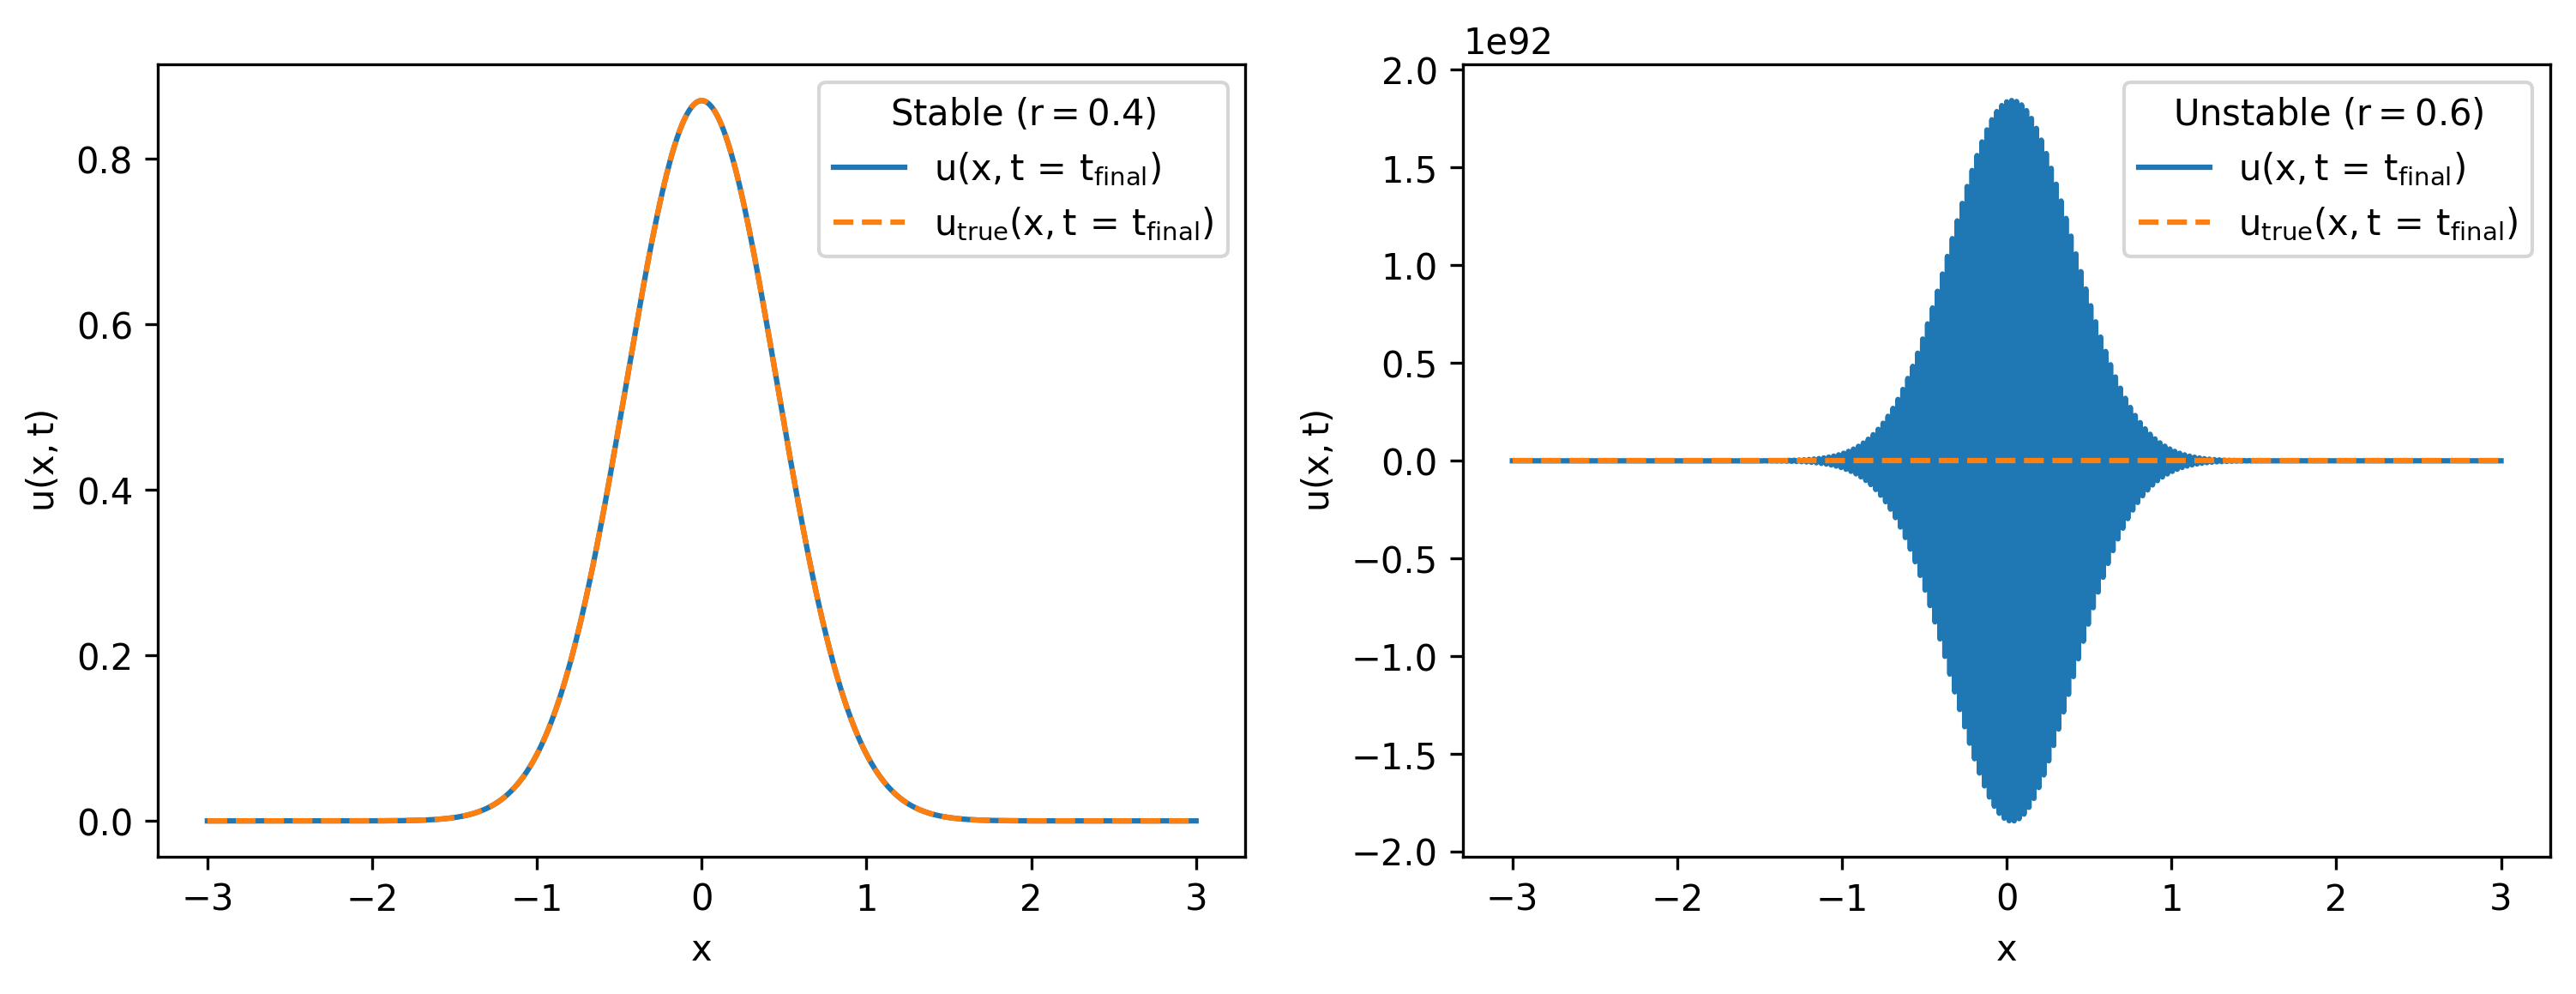

In [8]:
fig = plt.figure(figsize=(12,4),dpi = 300)

ax = fig.add_subplot(121)
#ax.plot(x, initial_conditions(x), label = 'u(x, t = 0)')
ax.plot(x, u_stable, label = r'$\rm u(x, t\,=\,t_{final})$')
ax.plot(x, u_true(x, t = 0.1), label = r'$\rm u_{true}(x, t\,=\,t_{final})$', linestyle = '--')
ax.set_xlabel('x')
ax.set_ylabel(r'$\rm u(x, t)$')
ax.legend(title = r'Stable ($\rm r = 0.4$)')

ax = fig.add_subplot(122)
#ax.plot(x, initial_conditions(x), label = 'u(x, t = 0)')
ax.plot(x, u_unstable, label = r'$\rm u(x, t\,=\,t_{final})$')
ax.plot(x, u_true(x, t = 0.1), label = r'$\rm u_{true}(x, t\,=\,t_{final})$', linestyle = '--')
ax.set_xlabel('x')
ax.set_ylabel(r'$\rm u(x, t)$')
ax.legend(title = r'Unstable ($\rm r = 0.6$)')
plt.show()

In [9]:
r = 2.
dt = r*dx**2/D
steps = int(np.ceil(t_final/dt))
dt = t_final/steps
r = D*dt/dx**2

In [10]:
u_cn = initial_conditions(x)
u_cn = apply_bc(u_cn)

times_cn = []
for n in range(steps):
    u_cn = crank_nicolson(u_cn, r)
    times_cn.append(n*dt)

u_fi = initial_conditions(x)
u_fi = apply_bc(u_fi)
times_fi = []
for n in range(steps):
    u_fi = fully_implicit(u_fi, r)
    times_fi.append(n*dt)

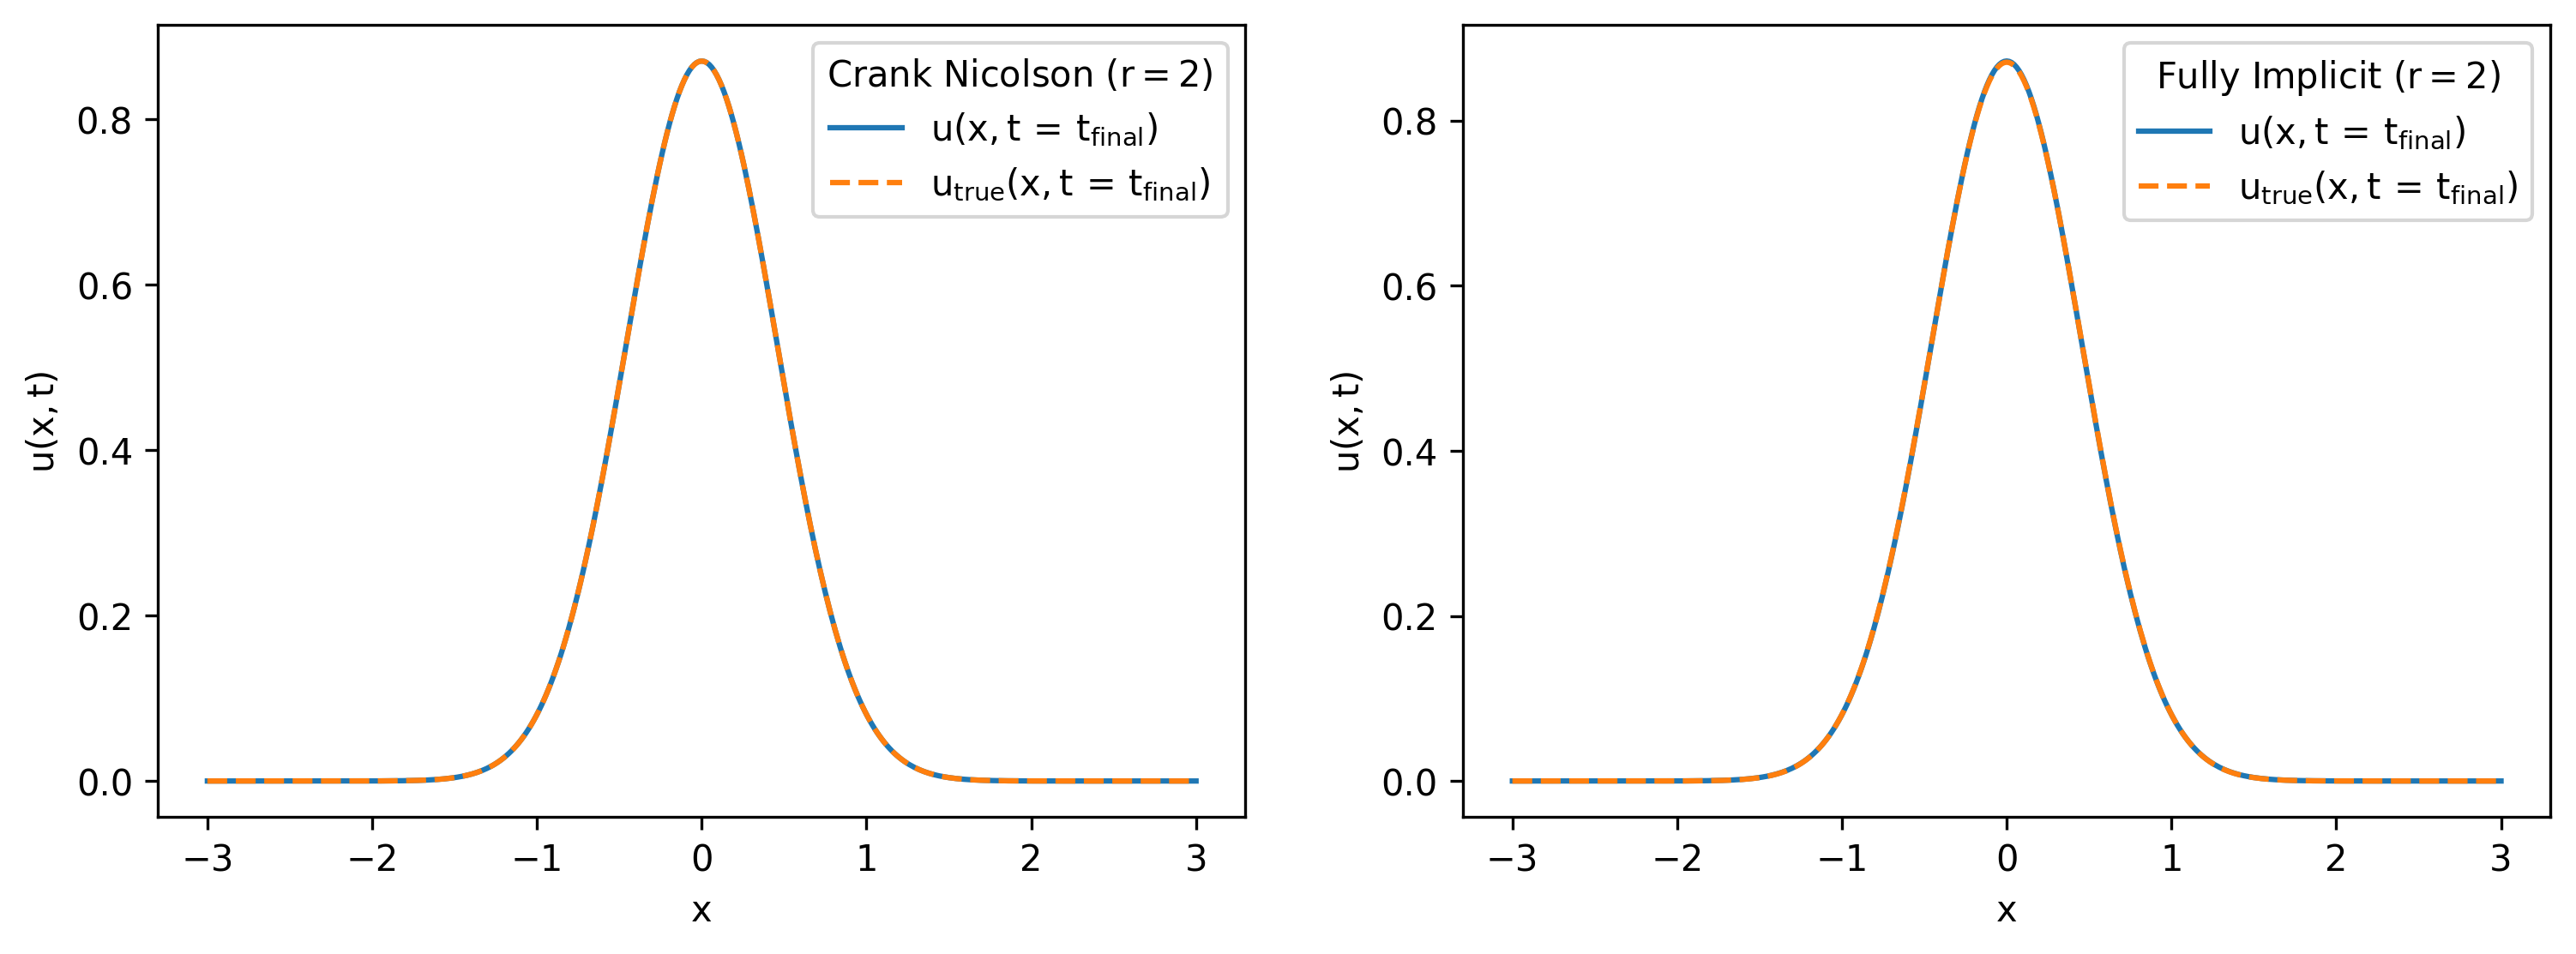

In [11]:
fig = plt.figure(figsize=(12,4),dpi = 300)

ax = fig.add_subplot(121)
#ax.plot(x, initial_conditions(x), label = 'u(x, t = 0)')
ax.plot(x, u_cn, label = r'$\rm u(x, t\,=\,t_{final})$')
ax.plot(x, u_true(x, t = 0.1), label = r'$\rm u_{true}(x, t\,=\,t_{final})$', linestyle = '--')
ax.set_xlabel('x')
ax.set_ylabel(r'$\rm u(x, t)$')
ax.legend(title = r'Crank Nicolson ($\rm r = 2$)')

ax = fig.add_subplot(122)
#ax.plot(x, initial_conditions(x), label = 'u(x, t = 0)')
ax.plot(x, u_fi, label = r'$\rm u(x, t\,=\,t_{final})$')
ax.plot(x, u_true(x, t = 0.1), label = r'$\rm u_{true}(x, t\,=\,t_{final})$', linestyle = '--')
ax.set_xlabel('x')
ax.set_ylabel(r'$\rm u(x, t)$')
ax.legend(title = r'Fully Implicit ($\rm r = 2$)')
plt.show()

In [12]:
Nx = [101, 201, 401, 801]

dxs = []
errs = []
for nx in Nx:
    x = np.linspace(-L, L, nx, endpoint='False')
    dx = x[1]-x[0]
    dt = dx**2
    steps = int(np.ceil(t_final/dt))
    dt = t_final/steps
    r = dt/dx**2   # recompute consistent r

    u = initial_conditions(x)
    u = apply_bc(u)
    
    for n in range(steps):
        u = crank_nicolson(u, r)
    
    u_exact = u_true(x, n*dt)
    L_inf = np.max(np.abs(u - u_exact))
    dxs.append(dx)
    errs.append(L_inf)

for i in range(len(errs)):
    p = np.log(errs[i]/errs[i-1]) / np.log(dxs[i]/dxs[i-1])
    print(f"Order of convergence: p = {p:.4f}")

Order of convergence: p = 2.0144
Order of convergence: p = 2.0427
Order of convergence: p = 1.9996
Order of convergence: p = 2.0008


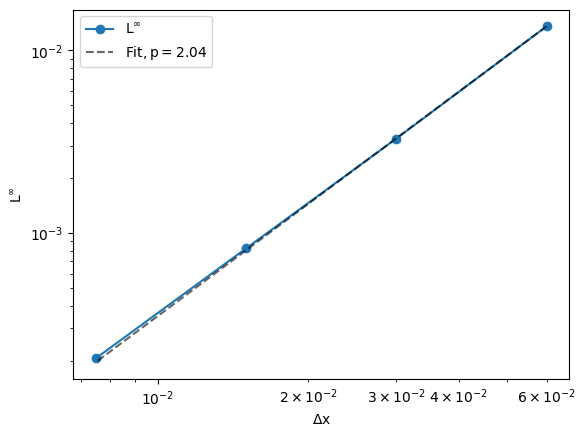

In [13]:
params, _ = curve_fit(model, dxs, errs)
A_fit, p_fit = params

plt.loglog(dxs, errs, 'o-', label=r'$\rm L^\infty$')
plt.loglog(dxs, model(dxs, A_fit, p_fit), '--', color = 'black', alpha = 0.6,label=rf'$\rm Fit, p = {p_fit:.2f} $')

plt.xlabel(r'$\rm\Delta x$')
plt.ylabel(r'$\rm L^\infty$')
plt.legend()
plt.show()